In [8]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Wilson–Cowan básico (1 nodo)
# -------------------------

def S(x, a, theta):
    return 1.0 / (1.0 + np.exp(-a * (x )))

def wc_rhs(state, params):
    E, I = state
    p = params

    dE = (-E + S(p["cEE"]*E - p["cEI"]*I + p["P"], p["aE"], p["thetaE"])) / p["tauE"]
    dI = (-I + S(p["cIE"]*E - p["cII"]*I + p["Q"], p["aI"], p["thetaI"])) / p["tauI"]

    return np.array([dE, dI])

def rk4_step(f, state, dt, params):
    k1 = f(state, params)
    k2 = f(state + 0.5*dt*k1, params)
    k3 = f(state + 0.5*dt*k2, params)
    k4 = f(state + dt*k3, params)
    return state + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

# --- reutilizamos funciones de antes ---

def simulate_wc(params, T=5.0, dt=1e-3):
    state = np.array([0.1, 0.1])
    n_steps = int(T / dt)

    traj = np.zeros((n_steps, 2))
    for i in range(n_steps):
        state = rk4_step(wc_rhs, state, dt, params)
        traj[i] = state

    return traj


def plot_phase(traj, title):
    # quitar transitorio
    traj_ss = traj[int(0.5 * len(traj)):]

    E = traj_ss[:, 0]
    I = traj_ss[:, 1]

    plt.figure(figsize=(4, 4))
    plt.plot(E, I, lw=1, label="Trajectory")

    # punto inicial (verde)
    plt.scatter(E[0], I[0], c="green", s=80, label="Start")

    # punto final (rojo)
    plt.scatter(E[-1], I[-1], c="red", s=80, label="End")

    plt.xlabel("E")
    plt.ylabel("I")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



def simulate_and_print(label, params, T=3.0, dt=1e-3):
    print(f"\n===== {label} =====")
    state = np.array([0.1, 0.1])
    E=[]

    n_steps = int(T/dt)
    for i in range(n_steps):
        state = rk4_step(wc_rhs, state, dt, params)
        E.append(state)

        # imprime cada 100 ms
        if i % int(0.1/dt) == 0:
            print(f"t={i*dt:4.2f}  E={state[0]:+.3f}")
    return E

def oscillates_by_variance(signal, tol=1e-3):
    return np.std(signal) > tol


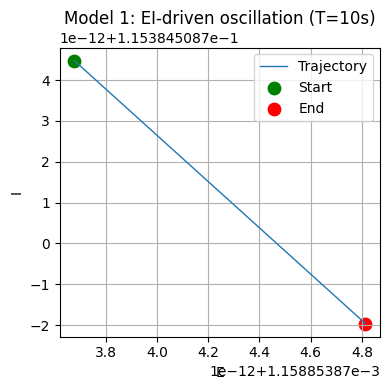

In [12]:
params_osc = dict(
    tauE=0.125,
    tauI=0.25,
    aE=1.5,
    aI=1.0,
    thetaE=2.0,
    thetaI=3.0,   # 🔑 CLAVE
    cEE=8.0,
    cEI=40.0,
    cIE=8.0,
    cII=0.4,
    P=0.1,
    Q=-2.0
)


dt = 1e-3
T = 10.0

traj = simulate_wc(params_osc, T=T, dt=dt)
plot_phase(traj, "Model 1: EI-driven oscillation (T=10s)")


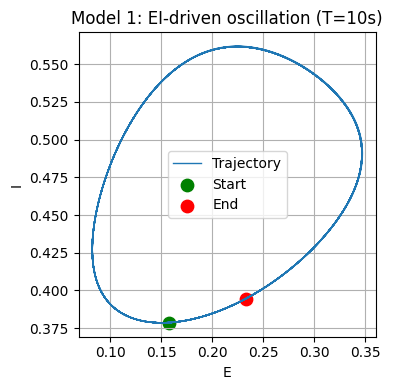

In [10]:
params_gain = dict(
    tauE=0.12,
    tauI=0.25,
    aE=2,      # mayor pendiente → más no linealidad
    aI=2,
    thetaE=2.0,
    thetaI=1.0,  # sigue en rango activo
    cEE=6.0,     # menos feedback excitatorio local
    cEI=11.0,    # feedback inhibitor moderado
    cIE=6.0,
    cII=0.4,
    P=3.0,       # mueve el punto de operación de E
    Q=-1.0
)



dt = 1e-3
T = 10.0

traj = simulate_wc(params_gain, T=T, dt=dt)
plot_phase(traj, "Model 1: EI-driven oscillation (T=10s)")


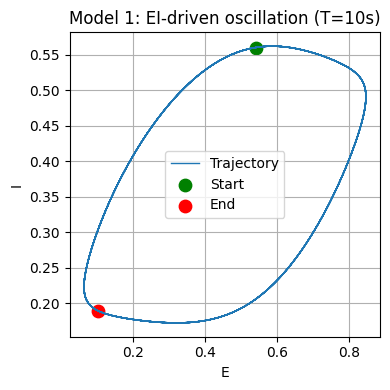

In [119]:
params_input_osc = dict(

    tauE=0.125,
    tauI=0.25,
    aE=3.0,      # pendiente intermedia
    aI=2.0,
    thetaE=2.0,
    thetaI=1.0,  # mantiene I en zona activa
    cEE=7.0,     # autoexcitación media
    cEI=15.0,    # feedback inhibitor
    cIE=5.0,
    cII=0.4,
    P=4.0,       # input ligeramente distinto
    Q=-1.0
)

params_input_osc = dict(
    tauE=0.125,
    tauI=0.25,
    aE=3.0,      # pendiente intermedia
    aI=2.0,
    thetaE=2.0,
    thetaI=1.0,  # mantiene I en zona activa
    cEE=7.0,     # autoexcitación media
    cEI=15.0,    # feedback inhibitor
    cIE=4.0,
    cII=0.4,
    P=4.0,       # input ligeramente distinto
    Q=-1.0
)


"""
tauE=0.12,
        tauI=0.25,
        aE=1.4,
        aI=1.0,
        thetaE=2.0,
        thetaI=1.0,
        cEE=7.0,
        cEI=8.0,
        cIE=7.0,
        cII=0.4,
        P=4.0,
        Q=-1.0
"""


dt = 1e-3
T = 10.0

traj = simulate_wc(params_input_osc, T=T, dt=dt)
plot_phase(traj, "Model 1: EI-driven oscillation (T=10s)")



In [136]:
params_osc = dict(
    tauE=0.125,
    tauI=0.25,
    aE=1.5,
    aI=1.0,
    thetaE=2.0,
    thetaI=3.0,   # 🔑 CLAVE
    cEE=8.0,
    cEI=40.0,
    cIE=8.0,
    cII=0.4,
    P=5.0,
    Q=-2.0
)

params_gain_2 = dict(
    tauE=0.12,
    tauI=0.25,
    aE=2,      # mayor pendiente → más no linealidad
    aI=2,
    thetaE=1.5,
    thetaI=3.5,  # sigue en rango activo
    cEE=8.0,     # menos feedback excitatorio local
    cEI=40.0,    # feedback inhibitor moderado
    cIE=6.0,
    cII=0.4,
    P=3.0,       # mueve el punto de operación de E
    Q=-1.0
)

params_input_osc = dict(
    tauE=0.12,
    tauI=0.25,
    aE=1.4,      # pendiente intermedia
    aI=1.0,
    thetaE=2.0,
    thetaI=1.0,  # mantiene I en zona activa
    cEE=7.0,     # autoexcitación media
    cEI=8.0,    # feedback inhibitor
    cIE=7.0,
    cII=0.4,
    P=4.0,       # input ligeramente distinto
    Q=-1.0
)

params_gain = dict(
    tauE=0.12,
    tauI=0.25,
    aE=2,      # mayor pendiente → más no linealidad
    aI=2,
    thetaE=2.0,
    thetaI=1.0,  # sigue en rango activo
    cEE=11.0,     # menos feedback excitatorio local
    cEI=11.0,    # feedback inhibitor moderado
    cIE=6.0,
    cII=0.4,
    P=3.0,       # mueve el punto de operación de E
    Q=-1.0
)



param_nodes = [
    params_osc,       # Nodo 0
    params_gain,      # Nodo 1
    params_input_osc  # Nodo 2
]


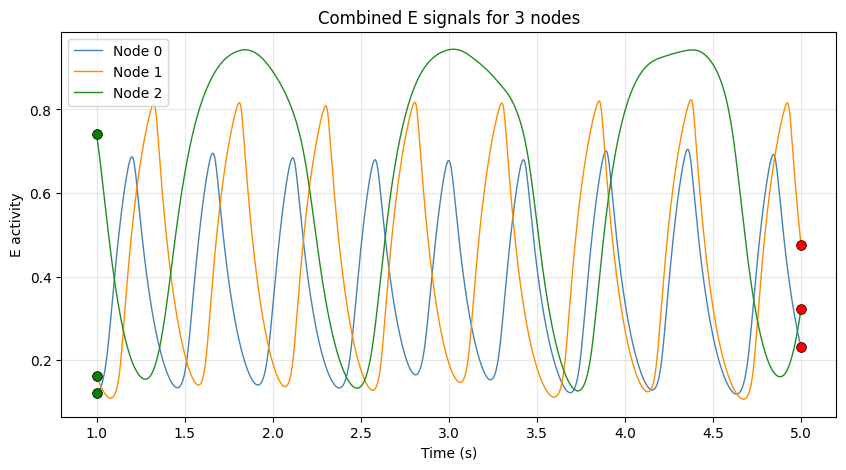

In [137]:
def wc_rhs_nodewise(state, K, M, param_nodes):
    """
    Wilson-Cowan RHS para N nodos, cada uno con sus parámetros distintos.
    state: vector [E0,E1,...,EN-1, I0,I1,...,IN-1]
    K: acoplamiento global
    M: matriz de conectividad (NxN)
    param_nodes: lista de diccionarios de parámetros por nodo
    """
    N = M.shape[0]
    E = state[:N]
    I = state[N:]

    dE_dt = np.zeros(N)
    dI_dt = np.zeros(N)

    for i in range(N):
        p = param_nodes[i]
        # Coupling desde otros nodos
        coupling = K * np.sum(M[i,:] * E)
        # E y I dynamics
        dE_dt[i] = (-E[i] + 1.0 / (1.0 + np.exp(-p['aE'] * (p['cEE']*E[i] - p['cEI']*I[i] + p['P'] + coupling - p['thetaE'])))) / p['tauE']
        dI_dt[i] = (-I[i] + 1.0 / (1.0 + np.exp(-p['aI'] * (p['cIE']*E[i] - p['cII']*I[i] + p['Q'] - p['thetaI'])))) / p['tauI']

    return np.concatenate([dE_dt, dI_dt])


def simulate_wc_nodewise(state0, K, M, param_nodes, T=10.0, dt=1e-3):
    n_steps = int(T / dt)
    N = M.shape[0]
    states = np.zeros((n_steps, 2*N))
    states[0] = state0
    t = np.linspace(0, T, n_steps)

    for i in range(1, n_steps):
        # RK4 step
        k1 = wc_rhs_nodewise(states[i-1], K, M, param_nodes)
        k2 = wc_rhs_nodewise(states[i-1] + 0.5*dt*k1, K, M, param_nodes)
        k3 = wc_rhs_nodewise(states[i-1] + 0.5*dt*k2, K, M, param_nodes)
        k4 = wc_rhs_nodewise(states[i-1] + dt*k3, K, M, param_nodes)
        states[i] = states[i-1] + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

    return t, states

def plot_combined_E_signals(t, states, N_nodes, transient_time=1.0, title="Wilson-Cowan Excitatory Signals"):
    """
    Plot the E signals of all nodes in a single figure, marking start (green) and end (red).

    Parameters:
    -----------
    t : ndarray
        Time vector
    states : ndarray
        Time series of [E0,...EN-1, I0,...IN-1]
    N_nodes : int
        Number of nodes
    transient_time : float
        Time to discard as transient
    title : str
        Plot title
    """
    dt = t[1] - t[0]
    start_idx = int(transient_time / dt)
    E = states[start_idx:, :N_nodes]
    t_plot = t[start_idx:]

    colors = ['steelblue', 'darkorange', 'forestgreen']
    plt.figure(figsize=(10,5))
    for i in range(N_nodes):
        plt.plot(t_plot, E[:, i], color=colors[i], lw=1, label=f'Node {i}')
        plt.scatter(t_plot[0], E[0,i], c='green', s=50, zorder=5, edgecolors='black', linewidths=0.5)
        plt.scatter(t_plot[-1], E[-1,i], c='red', s=50, zorder=5, edgecolors='black', linewidths=0.5)
    
    plt.xlabel("Time (s)")
    plt.ylabel("E activity")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()



N_nodes = 3
state0 = 0.1 * np.random.randn(2*N_nodes)  # pequeño ruido inicial
K = 0.5  # acoplamiento global
M = np.array([
    [0.0, 1.0, 1.0],
    [1.0, 0.0, 1.0],
    [1.0, 1.0, 0.0]
])

t, states = simulate_wc_nodewise(state0, K, M, param_nodes, T=10.0, dt=1e-3)

# Extraemos señales
E = states[:, :N_nodes]
I = states[:, N_nodes:]



# Simular
N_nodes = 3
state0 = 0.1 * np.random.randn(2*N_nodes)
K = 0.5
M = np.array([[0,1,1],[1,0,1],[1,1,0]])
param_nodes = [params_osc, params_gain_2, params_input_osc]

t, states = simulate_wc_nodewise(state0, K, M, param_nodes, T=5.0, dt=1e-3)

# Ploteo combinado
plot_combined_E_signals(t, states, N_nodes, transient_time=1.0, title="Combined E signals for 3 nodes")
